## Modelling Oleic acid and ozone reactions

Tracks the depletion of oleic acid, via radius, as it reacts with ozone.

The reaction modelled: oleic acid reacts with ozone, destroying both. The program shows the decrease in radius of the aerosol as this process occurs.

### Tracking the Reaction in terms of Number of Atoms

In [1]:
# Installing Packages

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

from numpy import random


In [2]:
# Creating Inputs
# UNITS

# assign
initial_radius = 5 # units?
mol_ozone_initial = 5 # maybe assign the number of MOLECULES of ozone instead

# constants

Na = 6.02e23

density_oleic_acid = 0.895 #g/ml 
density_ozone = 0.00214 # g/mL # redundant

mw_oleic_acid = 282.46 # g/mol
mw_ozone = 48.00 # g/mol


In [3]:
# defining functions
# check individual parts, then combine into one function for vol -> no atoms and vice versa

def volume(r):
    vol = (4/3)*(np.pi)*(r**3)
    return vol

def radius(V):
    rad = ((3/4*vol)/np.pi)**(1/3)

def mass(d, V):
    m = d * V
    return m

#def volume(m)

def number_of_moles(mw, m):
    moles = m / mw
    return moles

#def mass(moles)

def number_of_atoms(moles):
    atoms = moles * Na
    return atoms

#def moles(number_of_atoms)


In [4]:
# Initial readings for the sample of oleic acid

v0 = volume(initial_radius)
mass0 = mass(density_oleic_acid, v0)
moles0 = number_of_moles(mw_oleic_acid, mass0)
atoms0 = number_of_atoms(moles0)

atoms0_ozone = number_of_atoms(mol_ozone_initial)

print(f"The number of atoms for an initial radius of {initial_radius} is {atoms0}")
print(f"There are {atoms0_ozone} atoms of ozone")


The number of atoms for an initial radius of 5 is 9.98760122865565e+23
There are 3.01e+24 atoms of ozone


In [ ]:
# Creating Inputs

# Update to realistic k values later...
kf = 0.01
#kb = 0.01 # no backward reaction

# Calculation of equilibrium constant
#K = kf/kb

time_step = 1 # second
total_time = 600 # seconds for total run
ntime = int(total_time / time_step) # total number of calculations

# need to calculate with molecules: for 1:1 ratio of oleic acid reacting with ozone
# Initial paramaters
no_oleic_acid = atoms0
no_ozone = atoms0_ozone

#mol_oleic_acid = moles0
#mol_ozone = mol_ozone_initial # ???

time = 0

# Variables to be updated
oleic_remaining = no_oleic_acid
ozone_remaining = no_ozone

#G_formed = mol_ozone

# Creating lists
oleic = []
ozone = []
times = []
sum_mol = []

In [6]:
for t in range(ntime):

    time += time_step

    # Store current values
    oleic.append(oleic_remaining)
    ozone.append(ozone_remaining)
    times.append(time)

    # First-order rates
    reaction_rate = kf * oleic_remaining
    #condensation_rate = kb * G_formed

    # Integrate????????

    # Change in each species during this timestep
    dOleic = -reaction_rate * time_step
    dOzone = -reaction_rate * time_step

    # dL = (-evaporation_rate + condensation_rate) * time_step
    # dG = (evaporation_rate - condensation_rate) * time_step

    # Update populations
    oleic_remaining += dOleic
    ozone_remaining += dOzone

    # Total molecules
    sum_mol.append(oleic_remaining + ozone_remaining)

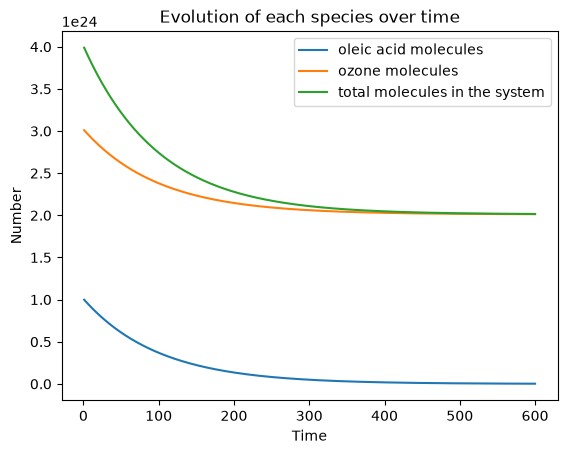

In [7]:
# Plotting evolution of species over time

plt.plot(times, oleic, label="oleic acid molecules")
plt.plot(times, ozone, label="ozone molecules")
plt.plot(times, sum_mol, label="total molecules in the system") # expect a straight line

plt.title("Evolution of each species over time")
plt.xlabel("Time")
plt.ylabel("Number")
plt.legend()

evident that ozone was in excess here as some remains after oleic acid depletions stopped.

note: if you get a shape size error:
    first try: restart and run all
    sometimes the time carries over if the cell is run a lot

### Tracking the Change in Volume of the Aerosol